# Data Preprocessing for Filtering



In [220]:
# import necessary libraries
import os
import math
import numpy as np
import pandas as pd
from scipy.ndimage import uniform_filter
import matplotlib.pyplot as plt

### Load the file

In [221]:
# File path 
file_path = "F:/wen_yu_cases/case2/new_dilute_files/fbr_2d_new_dilute_8s.csv"

# Load data
data = pd.read_csv(file_path)

# Clean column names and remove unnecessary columns
data.columns = data.columns.str.strip()
if 'cellnumber' in data.columns:
    data = data.drop(columns=['cellnumber'])

# Grid info
x_cells, y_cells = 224, 1200
x_length, y_length = 0.28, 1.5
dx = x_length / x_cells
dy = y_length / y_cells
Delta_g = dy  # fine grid spacing 

# Round coordinates to avoid floating point issues
precision = abs(int(np.floor(np.log10(dy)))) + 1
data['x-coordinate'] = data['x-coordinate'].round(precision)
data['y-coordinate'] = data['y-coordinate'].round(precision)

# print total unique coordinates for verification
# print("Total unique x-coordinates:", data['x-coordinate'].nunique())
# print("Total unique y-coordinates:", data['y-coordinate'].nunique())

# Sort by y first, then x
data = data.sort_values(by=['y-coordinate', 'x-coordinate']).reset_index(drop=True)

# Optional: remove freeboard (top cells) to focus on active bed
active_ny = 450  # adjust as needed


### post-processing calculations

In [222]:
# Favre quantities for y-velocity
data['alp_ug_y'] = data['gas-vof'] * data['gas-y-velocity']
data['alp_us_y'] = data['solid-vof'] * data['solid-y-velocity']

data['alp_ug_x'] = data['gas-vof'] * data['gas-x-velocity']
data['alp_us_x'] = data['solid-vof'] * data['solid-x-velocity']

# Drift velocity term
data['alp_s_ug_y'] = data['solid-vof'] * data['gas-y-velocity']

data.head()


,x-coordinate,y-coordinate,cell-id,gas-total-pressure,gas-density,gas-x-velocity,gas-y-velocity,gas-vof,solid-total-pressure,solid-density,solid-x-velocity,solid-y-velocity,solid-vof,solid-diameter,alp_ug_y,alp_us_y,alp_ug_x,alp_us_x,alp_s_ug_y
0,0.0006,0.7506,268201.0,289.712129,1.225,0.003845,-0.177178,0.830257,335.951556,2500.0,0.005753,-0.192286,0.169743,0.0003,-0.147104,-0.032639,0.003192,0.000977,-0.030075
1,0.0019,0.7506,267001.0,289.815465,1.225,0.018441,-0.373361,0.850801,493.300360,2500.0,0.033482,-0.402163,0.149199,0.0003,-0.317656,-0.060002,0.015690,0.004995,-0.055705
2,0.0031,0.7506,265801.0,290.018109,1.225,0.052310,-0.657502,0.892951,955.843376,2500.0,0.069598,-0.726656,0.107049,0.0003,-0.587118,-0.077788,0.046711,0.007450,-0.070385
3,0.0044,0.7506,264601.0,290.410757,1.225,0.099500,-1.010174,0.915344,1684.284294,2500.0,0.123685,-1.048955,0.084656,0.0003,-0.924656,-0.088801,0.091077,0.010471,-0.085518
4,0.0056,0.7506,263401.0,290.930829,1.225,0.144861,-1.334358,0.911695,2623.888647,2500.0,0.213860,-1.349634,0.088305,0.0003,-1.216529,-0.119179,0.132069,0.018885,-0.117830


In [223]:
#Calculate terminal velocity iteratively

g = 9.81            # m/s²
rho_g = 1.225       # kg/m³
rho_p = 2500        # kg/m³
mu_g = 1.8e-5       # Pa·s
dp = 300e-6          # m

def get_terminal_velocity(rho_p, rho_g, g, dp, mu_g): 
 # rho_p: density of the solid, 
 # rho_g: density of the fluid,
 # g: acceleration due to gravity,
 # dp: solid diameter
 # mu: dynamic viscosity of the fluid (gas)

 tol=1e-8
 delta= 2*tol
 count = 0
 max_count = 200
 CD=1 # drag coefficient (initialize with 1)...assumption

 while delta>tol and count<max_count:
    # calculate terminal velocity
    Ut = math.sqrt((4*dp*g*(rho_p - rho_g))/(3*CD*rho_g))
    # Reynolds number
    Ret = (rho_g*Ut*dp)/mu_g 
    
    if Ret < 1000:
        # Schiller-Naumann equation
        CD_new = (24/Ret)*(1 + 0.15*Ret**0.687) 
    else:
        CD_new = 0.44

    delta = abs(CD - CD_new)
    CD = CD_new
    count += 1
 print("Iterative process has converged in {:d} iterations".format(count))
 return Ut
Ut = get_terminal_velocity(rho_p, rho_g, g, dp, mu_g)
print("Terminal Velocity is: ", Ut)

# Now using Ut calculate particle reynolds number and Froude number
Re_p = (rho_g * Ut * dp) / mu_g
print("Particle Reynolds number is: ", Re_p)
Fr = Ut**2/(g*dp)
print("Froude number is: ", Fr)

# Let's calculate characteristic length scale L_c
Lc = dp*Fr**(1/3)
print("Characteristic length scale L_c is: ", Lc)

# Add Re_p and Fr to dataframe
data['Re_p'] = Re_p
data['Fr'] = Fr



Iterative process has converged in 15 iterations
Terminal Velocity is:  2.2232632008524815
Particle Reynolds number is:  45.3916236840715
Froude number is:  1679.544430942855
Characteristic length scale L_c is:  0.0035660307774051875


### Reshape Data into 2D Grids

In [224]:
# Convert all columns to numpy + reshape
grids = {}

for col in data.columns:
    arr = data[col].to_numpy().reshape(active_ny, x_cells)
    grids[col] = arr
solid_vof=grids['solid-vof']# print(solid_y_vel)
# average solid-vof in grids
average_solid_vof = np.mean(solid_vof)
print("Average solid-vof:", average_solid_vof)

Average solid-vof: 0.05430391568608869


### Apply spatial box filtering  

In [225]:
# Apply uniform filtering with different filter sizes
filter_sizes = [2, 6, 8, 10, 12, 16]
save_path = "F:/wen_yu_cases/case2/new_dilute_files/filtered_files"
os.makedirs(save_path, exist_ok=True) 

all_filtered_outputs = {}
def apply_filter(grid, size=2, mode='reflect'):
    return uniform_filter(grid, size=size, mode=mode)

for f in filter_sizes:
    print(f"\nApplying filter size = {f}")

    # Filter every variable except solid-density and solid-diameter and gas density
    filtered_grids_2d = {}
    filtered_grids_1d = {}
    for col in grids:
        if col not in ['x-coordinate', 'y-coordinate', 'cell-id','solid-density', 'solid-diameter', 'gas-density', 'Re_p', 'Fr']:
            filtered_grids_2d[col] = apply_filter(grids[col], size=f, mode='reflect')
        else:
            filtered_grids_2d[col] = grids[col]  # keep original
            
    # flatten arrays for dataframe
    for col in filtered_grids_2d:
        filtered_grids_1d[col] = filtered_grids_2d[col].flatten()
    
    # create dataframe to save
    df_filtered = pd.DataFrame(filtered_grids_1d)

    # apply favere averaging on velocity components
    df_filtered['ug_y_filtered'] = df_filtered['alp_ug_y'] / df_filtered['gas-vof']
    df_filtered['us_y_filtered'] = df_filtered['alp_us_y'] / df_filtered['solid-vof']
    df_filtered['ug_x_filtered'] = df_filtered['alp_ug_x'] / df_filtered['gas-vof']
    df_filtered['us_x_filtered'] = df_filtered['alp_us_x'] / df_filtered['solid-vof']

    # calculate slip velocity
    df_filtered['u_slip_y'] = df_filtered['ug_y_filtered'] - df_filtered['us_y_filtered']

    # calculate drift flux
    df_filtered['alp_vd'] = df_filtered['alp_s_ug_y'] - (df_filtered['solid-vof'] * df_filtered['ug_y_filtered'])

     # Particle relaxation times
    mu_g = 1.8e-5
    rho_g = 1.225
    nu_g = mu_g / rho_g
    d_p = data['solid-diameter'].iloc[0]
    rho_p = data['solid-density'].iloc[0]

    tau_p_St = rho_p * d_p**2 / (18 * mu_g)
    # full slip magnitude (norm)
    u_slip_mag = np.abs(df_filtered['u_slip_y'])
    Re_tilde = df_filtered['gas-vof'] * u_slip_mag * d_p / nu_g
    tau_p_tilde_inv = (1/tau_p_St) * (1 + 0.15 * Re_tilde**0.687) * df_filtered['gas-vof']**(-2.7)
    df_filtered['tau_p_tilde'] = 1 / tau_p_tilde_inv

    # Drift velocity per literature 
    # v_d = (φ_s·u_ḡ)/(φ_s̄) - ũ_g
    df_filtered['vd_y'] = df_filtered['alp_s_ug_y'] / df_filtered['solid-vof'] - df_filtered['ug_y_filtered']
    
    # Filtered drag force
    # F_y = (ρ_s φ_s / τ̃_p)(ũ_g - ũ_s) + (ρ_s / τ̃_p) φ_s v_d
    term1 = (df_filtered['solid-density'] * df_filtered['solid-vof'] / df_filtered['tau_p_tilde']) * df_filtered['u_slip_y']
    term2 = (df_filtered['solid-density'] / df_filtered['tau_p_tilde']) * df_filtered['solid-vof'] * df_filtered['vd_y']
    df_filtered['fd_y'] = term1 + term2
    
    #-------------------------------------------------------------------------------------------------------------------------------
    
    # (Optional, to check wen & yu drag)
    # Re_micro = df_filtered['gas-vof'] * u_slip_mag * d_p * rho_g / mu_g
    # C_D = 24 / Re_micro * (1 + 0.15 * Re_micro**0.687)
    # beta_micro = 0.75 * C_D * rho_g * df_filtered['gas-vof'] * \
    #              df_filtered['solid-vof'] * u_slip_mag / d_p * \
    #              df_filtered['gas-vof']**(-2.65)
    # df_filtered['fd_micro_y'] = beta_micro * df_filtered['u_slip_y']

    #-------------------------------------------------------------------------------------------------------------------------------

    # Filter length
    df_filtered['Delta_f'] = Delta_g * f

    # Calculate filtered pressure gradient in y-direction
    P = filtered_grids_2d['gas-total-pressure']
    dpdy = np.zeros_like(P)

    ny = P.shape[0]

    for j in range(1, ny-1):
        dpdy[j, :] = (P[j+1, :] - P[j-1, :]) / (2 * Delta_g * f)

    dpdy[0, :] = (P[1, :] - P[0, :]) / (Delta_g * f)
    dpdy[-1, :] = (P[-1, :] - P[-2, :]) / (Delta_g * f)

    df_filtered['dpdy_filtered'] = dpdy.flatten()
    # multiply dpdy_filtered with gas-vof to get effective pressure gradient
    df_filtered['alp_dpdy_filtered'] = df_filtered['dpdy_filtered'] * df_filtered['gas-vof']

    # Save to excel
    out_file = f"{save_path}/filter_size_{f}_t3.xlsx"
    df_filtered.to_excel(out_file, index=False)

    all_filtered_outputs[f] = df_filtered


Applying filter size = 2

Applying filter size = 6

Applying filter size = 8

Applying filter size = 10

Applying filter size = 12

Applying filter size = 16


# GNN Development

In [226]:
# !pip install torch_geometric


In [1]:
# import necessary libraries
import os
import torch
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import math
import scipy as sp
import warnings
warnings.filterwarnings("ignore")

### Data Loading and Preprocessing

In [230]:
# Calculate terminal velocity iteratively
# Parameters
g = 9.81            # m/s²
rho_g = 1.225       # kg/m³
rho_p = 2500        # kg/m³
mu_g = 1.8e-5       # Pa·s
dp = 75e-6         # m

def get_terminal_velocity(rho_p, rho_g, g, dp, mu_g): 
 # rho_p: density of the solid, 
 # rho_g: density of the fluid,
 # g: acceleration due to gravity,
 # dp: solid diameter
 # mu: dynamic viscosity of the fluid (gas)

 tol=1e-8
 delta= 2*tol
 count = 0
 max_count = 200
 CD=1 # drag coefficient (initialize with 1)...assumption

 while delta>tol and count<max_count:
    # calculate terminal velocity
    Ut = math.sqrt((4*dp*g*(rho_p - rho_g))/(3*CD*rho_g))
    # Reynolds number
    Ret = (rho_g*Ut*dp)/mu_g 
    
    if Ret < 1000:
        # Schiller-Naumann equation
        CD_new = (24/Ret)*(1 + 0.15*Ret**0.687) 
    else:
        CD_new = 0.44

    delta = abs(CD - CD_new)
    CD = CD_new
    count += 1
 print("Iterative process has converged in {:d} iterations".format(count))
 return Ut
Ut = get_terminal_velocity(rho_p, rho_g, g, dp, mu_g)
print("Terminal Velocity is: ", Ut)
# Now using Ut calculate particle reynolds number and Froude number
Re_p = (rho_g * Ut * dp) / mu_g
print("Particle Reynolds number is: ", Re_p)
Fr = Ut**2/(g*dp)
print("Froude number is: ", Fr)

# Let's calculate characteristic length scale L_c
Lc = dp*Fr**(1/3)
print("Characteristic length scale L_c is: ", Lc)

Iterative process has converged in 28 iterations
Terminal Velocity is:  0.3480815707017538
Particle Reynolds number is:  1.776666350456868
Froude number is:  164.67656114468232
Characteristic length scale L_c is:  0.000411091527800743


#### Case75
Iterative process has converged in 28 iterations
Terminal Velocity is:  0.3480815707017538
Particle Reynolds number is:  1.776666350456868
Froude number is:  164.67656114468232
Characteristic length scale L_c is:  0.000411091527800743

##### Case 300
Terminal Velocity is:  2.2232632008524815
Particle Reynolds number is:  45.3916236840715
Froude number is:  1679.544430942855
Characteristic length scale L_c is:  0.0035660307774051875

In [228]:
import glob
# Base path containing all folders
base_path = "./GNN_data"
# Separate folder groups
folders_275 = [
    "filtered_files_dense_275","filtered_files_moderate_dense_275",
    "filtered_files_dilute_275","filtered_files_highly_dilute_275", "filtered_files_added_275"
]

folders_300 = [
    "filtered_files_dense_300","filtered_files_moderate_dense_300",
    "filtered_files_dilute_300","filtered_files_highly_dilute_300","filtered_files_added_300"
]

folder_75=["filtered_files_dense_75","filtered_files_moderate_dense_75",
          "filtered_files_dilute_75","filtered_files_highly_dilute_75"]

# just use the required columns(features and target label)
required_cols = [ "gas-vof", "solid-vof", "alp_vd", "Re_p", "Fr", "u_slip_y", "Delta_f", "tau_p_tilde", "dpdy_filtered", "fd_y"]

# Load 275 group 
data_275 = []

for folder in folders_275:
    print(f"\nProcessing folder: {folder}")
    folder_path = os.path.join(base_path, folder)
    files = glob.glob(os.path.join(folder_path, "*.xlsx"))
    
    for file in files:
        # Skip temporary Excel files
        if os.path.basename(file).startswith("~$"):
            continue
        
        print(f"  Loading file: {os.path.basename(file)}")  # <-- track file being processed
        df = pd.read_excel(file, usecols=required_cols)
        
        sample = {
            "data": df,
            "folder": folder,
            "filename": os.path.basename(file)
        }
        data_275.append(sample)

print("\nFinished loading 275 group:", len(data_275), "files")
# Load 300 group 
data_300 = []

for folder in folders_300:
    print(f"\nProcessing folder: {folder}")
    folder_path = os.path.join(base_path, folder)
    files = glob.glob(os.path.join(folder_path, "*.xlsx"))
    
    for file in files:
        if os.path.basename(file).startswith("~$"):
            continue
        
        print(f"  Loading file: {os.path.basename(file)}")
        df = pd.read_excel(file, usecols=required_cols)
        
        sample = {
            "data": df,
            "folder": folder,
            "filename": os.path.basename(file)
        }
        data_300.append(sample)

print("\nFinished loading 300 group:", len(data_300), "files")
# Load 75 group
data_75 = []

for folder in folder_75:
    print(f"\nProcessing folder: {folder}")
    folder_path = os.path.join(base_path, folder)
    files = glob.glob(os.path.join(folder_path, "*.xlsx"))
    
    for file in files:
        if os.path.basename(file).startswith("~$"):
            continue
        
        print(f"  Loading file: {os.path.basename(file)}")
        df = pd.read_excel(file, usecols=required_cols)
        
        sample = {
            "data": df,
            "folder": folder,
            "filename": os.path.basename(file)
        }
        data_75.append(sample)
        
print("\nFinished loading 75 group:", len(data_75), "files")



Processing folder: filtered_files_dense_275
  Loading file: filter_size_10_t1.xlsx
  Loading file: filter_size_10_t2.xlsx
  Loading file: filter_size_10_t3.xlsx
  Loading file: filter_size_12_t1.xlsx
  Loading file: filter_size_12_t2.xlsx
  Loading file: filter_size_12_t3.xlsx
  Loading file: filter_size_16_t1.xlsx
  Loading file: filter_size_16_t2.xlsx
  Loading file: filter_size_16_t3.xlsx
  Loading file: filter_size_2_t1.xlsx
  Loading file: filter_size_2_t2.xlsx
  Loading file: filter_size_2_t3.xlsx
  Loading file: filter_size_6_t1.xlsx
  Loading file: filter_size_6_t2.xlsx
  Loading file: filter_size_6_t3.xlsx
  Loading file: filter_size_8_t1.xlsx
  Loading file: filter_size_8_t2.xlsx
  Loading file: filter_size_8_t3.xlsx

Processing folder: filtered_files_moderate_dense_275
  Loading file: filter_size_10_t1.xlsx
  Loading file: filter_size_10_t2.xlsx
  Loading file: filter_size_10_t3.xlsx
  Loading file: filter_size_12_t1.xlsx
  Loading file: filter_size_12_t2.xlsx
  Loading fil

In [254]:
# Save the data as pickle files
import pickle

# --- Save inside GNN_data folder ---
pickle_dir = "./GNN_data/data_pickles"
os.makedirs(pickle_dir, exist_ok=True)  # create folder if it doesn't exist
    
# Define pickle file paths
data_275_pickle = os.path.join(pickle_dir, "data_275.pkl")
data_300_pickle = os.path.join(pickle_dir, "data_300.pkl")
data_75_pickle = os.path.join(pickle_dir, "data_75.pkl")

# --- Save the data ---
with open(data_275_pickle, "wb") as f:
    pickle.dump(data_275, f)

with open(data_300_pickle, "wb") as f:
    pickle.dump(data_300, f)

with open(data_75_pickle, "wb") as f:
    pickle.dump(data_75, f)

print(f"Pickle files saved inside {pickle_dir}")


Pickle files saved inside ./GNN_data/data_pickles


### Scale Data for generalization


In [255]:
# --- Scaling constants ---
alp_max = 0.63
rho_s   = 2500
g       = 9.81

# Group-specific constants
Ut_275 = 2.026610816690855
Lc_275 = 0.00316358152730544

Ut_300 = 2.2232632008524815
Lc_300 = 0.0035660307774051875

Ut_75 = 0.3480815707017538
Lc_75 = 0.000411091527800743

#  Scale 275 group 
for sample in data_275:
    df = sample["data"].copy()       # copy to avoid accidental reference issues
    df["solid-vof"] = df["solid-vof"] / alp_max
    df["alp_vd"]    = df["alp_vd"] / (alp_max * Ut_275)
    df["u_slip_y"]  = df["u_slip_y"] / Ut_275
    df["Delta_f"]   = df["Delta_f"] / Lc_275
    df["dpdy_filtered"] = df["dpdy_filtered"] / (rho_s * g)
    df['fd_y'] = df['fd_y'] / (rho_s * g)
    sample["data"] = df               # update DataFrame in the sample

#  Scale 300 group 
for sample in data_300:
    df = sample["data"].copy()
    df["solid-vof"] = df["solid-vof"] / alp_max
    df["alp_vd"]    = df["alp_vd"] / (alp_max * Ut_300)
    df["u_slip_y"]  = df["u_slip_y"] / Ut_300
    df["Delta_f"]   = df["Delta_f"] / Lc_300
    df["dpdy_filtered"] = df["dpdy_filtered"] / (rho_s * g)
    df['fd_y'] = df['fd_y'] / (rho_s * g)
    sample["data"] = df
# Scale 75 group
for sample in data_75:
    df = sample["data"].copy()
    df["solid-vof"] = df["solid-vof"] / alp_max
    df["alp_vd"]    = df["alp_vd"] / (alp_max * Ut_75)
    df["u_slip_y"]  = df["u_slip_y"] / Ut_75
    df["Delta_f"]   = df["Delta_f"] / Lc_75
    df["dpdy_filtered"] = df["dpdy_filtered"] / (rho_s * g)
    df['fd_y'] = df['fd_y'] / (rho_s * g)
    sample["data"] = df

In [256]:
with open("./GNN_data/data_pickles/data_275.pkl", "rb") as f:
    data_275 = pickle.load(f)
with open("./GNN_data/data_pickles/data_300.pkl", "rb") as f:
    data_300 = pickle.load(f)
with open("./GNN_data/data_pickles/data_75.pkl", "rb") as f:
    data_75 = pickle.load(f)
#  Scale 275 group
with open("./GNN_data/scaled_data_pickles/scaled_data_275.pkl", "rb") as f:
    scaled_data_275 = pickle.load(f)
with open("./GNN_data/scaled_data_pickles/scaled_data_300.pkl", "rb") as f:
    scaled_data_300 = pickle.load(f)
with open("./GNN_data/scaled_data_pickles/scaled_data_75.pkl", "rb") as f:
    scaled_data_75 = pickle.load(f)

In [266]:
import os
import pickle
import pandas as pd

# --- Scaling constants ---
alp_max = 0.63
rho_s   = 2500
g       = 9.81

# Group-specific constants
scaling_params = {
    "275": {"Ut": 2.026610816690855, "Lc": 0.00316358152730544},
    "300": {"Ut": 2.2232632008524815, "Lc": 0.0035660307774051875},
    "75":  {"Ut": 0.3480815707017538, "Lc": 0.000411091527800743},
}

# --- Paths ---
raw_pickle_dir    = "./GNN_data/data_pickles"
scaled_pickle_dir = "./GNN_data/scaled_data_pickles"
os.makedirs(scaled_pickle_dir, exist_ok=True)

group_files = {
    "275": "data_275.pkl",
    "300": "data_300.pkl",
    "75":  "data_75.pkl"
}

# --- Load, preprocess, scale, and save ---
for group, filename in group_files.items():
    # Load raw data
    with open(os.path.join(raw_pickle_dir, filename), "rb") as f:
        data_group = pickle.load(f)

    print(f"\nProcessing group {group}, {len(data_group)} files")

    Ut = scaling_params[group]["Ut"]
    Lc = scaling_params[group]["Lc"]

    # Loop through each file/sample
    for sample in data_group:
        df = sample["data"].copy()  # copy to avoid modifying original accidentally

        # --- Fill missing values with column mean ---
        df.fillna(df.mean(), inplace=True)

        # --- Scaling ---
        df["solid-vof"]     = df["solid-vof"] / alp_max
        df["alp_vd"]        = df["alp_vd"] / Ut
        df["u_slip_y"]      = df["u_slip_y"] / Ut
        df["Delta_f"]       = df["Delta_f"] / Lc
        df["dpdy_filtered"] = df["dpdy_filtered"] / (rho_s * g)
        df["fd_y"]          = df["fd_y"] / (rho_s * g)

        # --- Update sample ---
        sample["data"] = df
        sample["scaled"] = True
        sample["meta"] = {"Ut": Ut, "Lc": Lc, "alp_max": alp_max}

    # --- Save scaled pickle ---
    scaled_filename = f"scaled_data_{group}.pkl"
    with open(os.path.join(scaled_pickle_dir, scaled_filename), "wb") as f:
        pickle.dump(data_group, f)

    print(f"Saved scaled data for group {group} as {scaled_filename}")



Processing group 275, 90 files
Saved scaled data for group 275 as scaled_data_275.pkl

Processing group 300, 90 files
Saved scaled data for group 300 as scaled_data_300.pkl

Processing group 75, 72 files
Saved scaled data for group 75 as scaled_data_75.pkl


In [273]:
with open("./GNN_data/scaled_data_pickles/scaled_data_275.pkl", "rb") as f:
    scaled_data_275 = pickle.load(f)

print(scaled_data_275[45]["data"].head())

    gas-vof  solid-vof       Re_p           Fr  u_slip_y    alp_vd  \
0  0.785932   0.339791  37.928584  1522.435883  0.433997  0.000000   
1  0.794401   0.326348  37.928584  1522.435883  0.417150  0.000196   
2  0.827662   0.273552  37.928584  1522.435883  0.391654  0.000319   
3  0.855994   0.228581  37.928584  1522.435883  0.391149 -0.000019   
4  0.849520   0.238857  37.928584  1522.435883  0.405125  0.000011   

   tau_p_tilde      fd_y   Delta_f  dpdy_filtered  
0     0.162768  0.117915  0.790244      -0.125651  
1     0.169093  0.105021  0.790244      -0.121839  
2     0.190213  0.073654  0.790244      -0.112131  
3     0.206191  0.056417  0.790244      -0.112564  
4     0.200241  0.062906  0.790244      -0.145001  


### GNN

In [31]:
import pickle
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [32]:
with open("./GNN_data/scaled_data_pickles/scaled_data_275.pkl", "rb") as f:
    scaled_data_275 = pickle.load(f)
with open("./GNN_data/scaled_data_pickles/scaled_data_300.pkl", "rb") as f:
    scaled_data_300 = pickle.load(f)
with open("./GNN_data/scaled_data_pickles/scaled_data_75.pkl", "rb") as f:
    scaled_data_75 = pickle.load(f)
print("Data loaded. Sample sizes - 275:", len(scaled_data_275), 
      ", 300:", len(scaled_data_300), ", 75:", len(scaled_data_75)) 

Data loaded. Sample sizes - 275: 90 , 300: 90 , 75: 72


In [33]:
data = scaled_data_275 + scaled_data_300 + scaled_data_75
ny, nx = 450, 224
N= ny* nx
print("Total graph samples:", len(data))
for i in range(3):
    df = data[i]["data"]
    print(f"Sample {i} rows:", df.shape[0])
    print("Columns:", df.columns.tolist())
feature_cols = ['solid-vof', 'u_slip_y','dpdy_filtered']
label_cols   = ['alp_vd']

Total graph samples: 252
Sample 0 rows: 100800
Columns: ['gas-vof', 'solid-vof', 'Re_p', 'Fr', 'u_slip_y', 'alp_vd', 'tau_p_tilde', 'fd_y', 'Delta_f', 'dpdy_filtered', 'Ut']
Sample 1 rows: 100800
Columns: ['gas-vof', 'solid-vof', 'Re_p', 'Fr', 'u_slip_y', 'alp_vd', 'tau_p_tilde', 'fd_y', 'Delta_f', 'dpdy_filtered', 'Ut']
Sample 2 rows: 100800
Columns: ['gas-vof', 'solid-vof', 'Re_p', 'Fr', 'u_slip_y', 'alp_vd', 'tau_p_tilde', 'fd_y', 'Delta_f', 'dpdy_filtered', 'Ut']


In [34]:
graphs = []
for sample in data:
    df = sample["data"]
    X = df[feature_cols].values.reshape(ny,nx,-1)
    y = df[label_cols].values.reshape(ny,nx,-1)
    graphs.append({
        "case": sample["folder"],
        "filename": sample["filename"],
        "X_grid": X,
        "y_grid": y
    })

print("Graphs prepared:", len(graphs))
print("Example shapes:", graphs[0]["X_grid"].shape, graphs[0]["y_grid"].shape)


Graphs prepared: 252
Example shapes: (450, 224, 3) (450, 224, 1)


### Node creation

In [36]:
for g in graphs:
    X_flat = g["X_grid"].reshape(-1, g["X_grid"].shape[2]) # 100800 x 5 
    y_flat = g["y_grid"].reshape(-1, 1) # 100800 x 1
    g["X_flat"] = X_flat 
    g["y_flat"] = y_flat
print("Example flattened shapes:", graphs[10]["X_flat"].shape, graphs[143]["y_flat"].shape)


Example flattened shapes: (100800, 3) (100800, 1)


### Edge Index Creation

In [37]:
def build_undirected_grid_edges(ny, nx):
    edges = []

    for i in range(ny):
        for j in range(nx):
            node_id = i * nx + j

            # Only add "forward" neighbors to avoid duplicates
            forward_neighbors = [
                (i, j+1),     # right
                (i+1, j),     # down
                (i+1, j+1),   # down-right
                (i+1, j-1)    # down-left
            ]

            for ni, nj in forward_neighbors:
                if 0 <= ni < ny and 0 <= nj < nx:
                    neighbor_id = ni * nx + nj
                    edges.append([node_id, neighbor_id])

    # Mirror edges to make undirected
    edge_list = edges.copy()
    for a, b in edges:
        edge_list.append([b, a])

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    return edge_index

# Example usage
ny, nx = 450, 224
edge_index = build_undirected_grid_edges(ny, nx)
print("Edge index shape:", edge_index.shape)  # Should be [2, 802360]


Edge index shape: torch.Size([2, 802360])


### Visualize the graph

In [121]:
# import matplotlib.pyplot as plt
# import networkx as nx
# # take one graph
# g = graphs[0]         

# # size of patch to visualize (KEEP SMALL)
# ny_s, nx_s = 10, 10   


# X_patch = g["X_grid"][:ny_s, :nx_s, :]   # (ny_s, nx_s, features)
# y_patch = g["y_grid"][:ny_s, :nx_s, :]   # (ny_s, nx_s, 1)

# X_flat = X_patch.reshape(-1, X_patch.shape[2])
# y_flat = y_patch.reshape(-1, 1)

# edges = []
# for i in range(ny_s):
#     for j in range(nx_s):
#         node_id = i * nx_s + j
        
#         if i < ny_s - 1:
#             edges.append([node_id, (i+1)*nx_s + j])
#         if j < nx_s - 1:
#             edges.append([node_id, i*nx_s + (j+1)])

#         # diagonals
#         if i < ny_s - 1 and j > 0:   
#             edges.append([node_id, (i+1)*nx_s + (j-1)])
#         if i < ny_s - 1 and j < nx_s - 1:  
#             edges.append([node_id, (i+1)*nx_s + (j+1)])
            

# edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()


# data_small = Data( x=torch.tensor(X_flat, dtype=torch.float),
#     y=torch.tensor(y_flat, dtype=torch.float),
#     edge_index=edge_index)

# G = nx.Graph()
# pos = {}

# for i in range(ny_s):
#     for j in range(nx_s):
#         node_id = i * nx_s + j
#         G.add_node(node_id)
#         pos[node_id] = (j, -i)   

# edge_list = data_small.edge_index.t().numpy()
# for u, v in edge_list:
#     G.add_edge(u, v)

# node_colors = y_flat.squeeze()   

# plt.figure(figsize=(6, 6))
# nx.draw(
#     G,
#     pos=pos,
#     node_size=60,
#     node_color=node_colors,
#     cmap="viridis",
#     edge_color="black",
#     width=0.7,
#     with_labels=False
# )

# plt.title("2D Grid Graph with 8-Neighbor Connections")
# plt.axis("equal")
# plt.axis("off")
# plt.show()


In [38]:
train_graphs = [g for g in graphs if "t1" in g["filename"] or "t2" in g["filename"]]
test_graphs  = [g for g in graphs if "t3" in g["filename"]]

print("Train graphs:", len(train_graphs))
print("Test graphs:", len(test_graphs))

Train graphs: 168
Test graphs: 84


In [39]:
from torch_geometric.data import Data
g=test_graphs[0]
data_object = Data(x=torch.tensor(g["X_flat"], dtype=torch.float),
            y=torch.tensor(g["y_flat"], dtype=torch.float),
            edge_index=edge_index)
print(data_object)

Data(x=[100800, 3], edge_index=[2, 802360], y=[100800, 1])


In [40]:
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv

class GCNRegressor(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, 128)  
        self.conv2 = GCNConv(128, 64)          
        self.conv3 = GCNConv(64, 8)             
        self.lin   = nn.Linear(8, 1)            

    def forward(self, x, edge_index):
        h = torch.relu(self.conv1(x, edge_index))
        h = torch.relu(self.conv2(h, edge_index))
        h = torch.relu(self.conv3(h, edge_index))
        out = self.lin(h)
        return h, out
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model=GCNRegressor(in_channels=len(feature_cols)).to(device)
print(model)

GCNRegressor(
  (conv1): GCNConv(3, 128)
  (conv2): GCNConv(128, 64)
  (conv3): GCNConv(64, 8)
  (lin): Linear(in_features=8, out_features=1, bias=True)
)


In [41]:
# Prepare PyG Data objects
train_data_objects = [
    Data(
        x=torch.tensor(g["X_flat"], dtype=torch.float),
        y=torch.tensor(g["y_flat"], dtype=torch.float),
        edge_index=edge_index,
        num_nodes=g["X_flat"].shape[0]
    ) for g in train_graphs
]
test_data_objects = [
    Data(
        x=torch.tensor(g["X_flat"], dtype=torch.float),
        y=torch.tensor(g["y_flat"], dtype=torch.float),
        edge_index=edge_index,
        num_nodes=g["X_flat"].shape[0]
    ) for g in test_graphs
]
print(train_data_objects[167])

Data(x=[100800, 3], edge_index=[2, 802360], y=[100800, 1], num_nodes=100800)


In [42]:
# K-Fold Cross Validation
k = 8
num_epochs = 300
patience = 20

kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_results = []

# Track per-fold metrics for visualization
train_losses_per_fold = []
val_losses_per_fold = []
val_r2_per_fold = []

for fold, (train_idx, val_idx) in enumerate(kf.split(train_data_objects)):
    print(f"\n===== Fold {fold+1}/{k} =====")
    
    train_subset = [train_data_objects[i] for i in train_idx]
    val_subset   = [train_data_objects[i] for i in val_idx]
    
    train_loader = DataLoader(train_subset, batch_size=1, shuffle=True)
    val_loader   = DataLoader(val_subset, batch_size=1, shuffle=False)
    
    model=GCNRegressor(in_channels=len(feature_cols)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    
    best_val_loss = np.inf
    best_embeddings = None
    counter = 0

    # Track losses per epoch
    train_losses = []
    val_losses = []
    val_r2s = []

    for epoch in range(num_epochs):
        # Training
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            h, pred = model(batch.x, batch.edge_index)
            loss = loss_fn(pred, batch.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0
        val_y_true, val_y_pred = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                h, pred = model(batch.x, batch.edge_index)
                val_loss += loss_fn(pred, batch.y).item()
                val_y_true.append(batch.y.cpu().numpy())
                val_y_pred.append(pred.cpu().numpy())
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        val_y_true = np.vstack(val_y_true)
        val_y_pred = np.vstack(val_y_pred)
        r2 = r2_score(val_y_true, val_y_pred)
        val_r2s.append(r2)

        # Save best embeddings
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_embeddings = h.cpu().detach()
            counter = 0
            torch.save({
                "model_state": model.state_dict(),
                "embeddings": best_embeddings
            }, f"best_3_marker_model_fold{fold}.pt")
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered")
                break

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Train MSE={avg_train_loss:.6f}, Val MSE={avg_val_loss:.6f}, R2={r2:.4f}")

    fold_results.append(best_val_loss)
    train_losses_per_fold.append(train_losses)
    val_losses_per_fold.append(val_losses)
    val_r2_per_fold.append(val_r2s)


===== Fold 1/8 =====
Epoch 0: Train MSE=0.008627, Val MSE=0.004777, R2=0.0844
Epoch 10: Train MSE=0.001570, Val MSE=0.001497, R2=0.7131
Epoch 20: Train MSE=0.000979, Val MSE=0.000913, R2=0.8250
Epoch 30: Train MSE=0.000662, Val MSE=0.002407, R2=0.5388
Epoch 40: Train MSE=0.000626, Val MSE=0.000591, R2=0.8867
Epoch 50: Train MSE=0.000958, Val MSE=0.000613, R2=0.8825
Epoch 60: Train MSE=0.000506, Val MSE=0.000917, R2=0.8242
Epoch 70: Train MSE=0.000530, Val MSE=0.001078, R2=0.7934
Epoch 80: Train MSE=0.000574, Val MSE=0.000604, R2=0.8843
Epoch 90: Train MSE=0.000521, Val MSE=0.000530, R2=0.8985
Epoch 100: Train MSE=0.000548, Val MSE=0.000473, R2=0.9094
Epoch 110: Train MSE=0.000506, Val MSE=0.000483, R2=0.9075
Epoch 120: Train MSE=0.000437, Val MSE=0.000459, R2=0.9120
Epoch 130: Train MSE=0.000484, Val MSE=0.000456, R2=0.9126
Epoch 140: Train MSE=0.000448, Val MSE=0.000600, R2=0.8850
Epoch 150: Train MSE=0.000420, Val MSE=0.000472, R2=0.9096
Epoch 160: Train MSE=0.000432, Val MSE=0.0004

In [43]:
# best fold = best model
best_fold_idx = np.argmin(fold_results)
print("Best fold for testing:", best_fold_idx)

checkpoint = torch.load(f"best_3_marker_model_fold{best_fold_idx}.pt")
model.load_state_dict(checkpoint["model_state"])
model.eval()

Best fold for testing: 3


GCNRegressor(
  (conv1): GCNConv(3, 128)
  (conv2): GCNConv(128, 64)
  (conv3): GCNConv(64, 8)
  (lin): Linear(in_features=8, out_features=1, bias=True)
)

In [44]:
# here we have saved the weights and biases
torch.save({
    "model_state": model.state_dict(),
    "feature_cols": feature_cols,
    "best_fold": best_fold_idx
}, "final_3_marker_gcn_DF_model.pt")


In [45]:
# here we have saved the losses during training for later plotting
# After training all folds
torch.save({
    "train_losses_per_fold": train_losses_per_fold,
    "val_losses_per_fold": val_losses_per_fold,
    "val_r2_per_fold": val_r2_per_fold
}, "training_history_3_marker_DF_model.pt")

# #To plot losses later
# history = torch.load(
#     "training_history_3_marker_DF_model.pt",
#     weights_only=False   # IMPORTANT
# )

# train_losses_per_fold = history["train_losses_per_fold"]
# val_losses_per_fold   = history["val_losses_per_fold"]
# val_r2_per_fold       = history["val_r2_per_fold"]



In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model = GCNRegressor(in_channels=3).to(device)

# checkpoint = torch.load(
#     "final_gcn_model.pt",
#     map_location=device,
#     weights_only=False
# )

# model.load_state_dict(checkpoint["model_state"])
# model.eval()


GCNRegressor(
  (conv1): GCNConv(3, 128)
  (conv2): GCNConv(128, 64)
  (conv3): GCNConv(64, 8)
  (lin): Linear(in_features=8, out_features=1, bias=True)
)

In [49]:
with torch.no_grad():
    embeddings, predictions = model(graph.x, graph.edge_index)

# Convert to CPU for plotting
embeddings = embeddings.cpu().numpy()
y_true = graph.y.cpu().numpy()


In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, BatchNorm
import numpy as np

# -------------------
# 1️⃣ Define the model exactly as it was trained
# -------------------
class GCNRegressor(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, 128)  
        self.conv2 = GCNConv(128, 64)          
        self.conv3 = GCNConv(64, 8)             
        self.lin   = nn.Linear(8, 1)            

    def forward(self, x, edge_index):
        h = torch.relu(self.conv1(x, edge_index))
        h = torch.relu(self.conv2(h, edge_index))
        h = torch.relu(self.conv3(h, edge_index))
        out = self.lin(h)
        return h, out

# -------------------
# 2️⃣ Load the saved model
# -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
in_channels = 3  # change to number of features in your data
model = GCNRegressor(in_channels).to(device)

checkpoint = torch.load("final_gcn_model.pt", map_location=device,weights_only=False)
model.load_state_dict(checkpoint["model_state"])
model.eval()

# -------------------
# 3️⃣ Pick a graph
# -------------------
graph = train_data_objects[0]  # pick first graph
graph = graph.to(device)

# -------------------
# 4️⃣ Get embeddings
# -------------------
with torch.no_grad():
    embeddings, predictions = model(graph.x, graph.edge_index)  # embeddings is still a torch.Tensor

# -------------------
# 5️⃣ Convert embeddings to NumPy (CORRECT ORDER)
# -------------------
# Important: embeddings must be a torch.Tensor at this point
embeddings_np = embeddings.detach().cpu().numpy()  # detach() ensures no gradient tracking
print("Final embeddings shape:", embeddings_np.shape)
print("First 10 embeddings:\n", embeddings_np[:10])


Final embeddings shape: (100800, 8)
First 10 embeddings:
 [[0.45128867 0.02037842 0.36897385 0.13994597 0.         0.
  0.         0.        ]
 [0.5275145  0.03190921 0.4188366  0.1750211  0.         0.
  0.         0.        ]
 [0.5100473  0.03205556 0.40527076 0.16578911 0.         0.
  0.         0.        ]
 [0.49807733 0.02392286 0.39808983 0.16368604 0.         0.
  0.         0.        ]
 [0.48937204 0.02064944 0.394718   0.16125624 0.         0.
  0.         0.        ]
 [0.4837523  0.0222403  0.39370954 0.15801542 0.         0.
  0.         0.        ]
 [0.47732764 0.02575025 0.39318228 0.15352626 0.         0.
  0.         0.        ]
 [0.4696902  0.02959578 0.39242107 0.14803888 0.         0.
  0.         0.        ]
 [0.46079063 0.03278307 0.39102125 0.14163361 0.         0.
  0.         0.        ]
 [0.45141804 0.03534495 0.3890947  0.13460578 0.         0.
  0.         0.        ]]


In [9]:
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt

# pca = PCA(n_components=2)
# emb_2d = pca.fit_transform(embeddings_np)
# sample_idx = np.random.choice(len(embeddings_np), size=5000, replace=False)
# plt.scatter(emb_2d[sample_idx,0], emb_2d[sample_idx,1], c=y_true[sample_idx], s=5, cmap='plasma')
# plt.scatter(emb_2d[:,0], emb_2d[:,1], c=y_true, s=0.5, alpha=0.3)

# plt.colorbar(label="Filtered drag")
# plt.show()


In [8]:
# # PCA to 2D
# from sklearn.decomposition import PCA

# pca = PCA(n_components=2)
# emb_2d = pca.fit_transform(embeddings)

# # Scatter plot, colored by true filtered drag
# plt.figure(figsize=(6,6))
# plt.scatter(emb_2d[:,0], emb_2d[:,1], c=y_true, cmap='viridis', s=10)
# plt.colorbar(label='Filtered Drag')
# plt.title('Node Embeddings of Graph (PCA 2D)')
# plt.xlabel('PC1')
# plt.ylabel('PC2')
# plt.show()


### Save the 3-marker model （diagonal)

In [ ]:
# here we have saved the weights and biases
torch.save({
    "model_state": model.state_dict(),
    "feature_cols": feature_cols,
    "best_fold": best_fold_idx
}, "final_gcn_model.pt")

# Load the trained model for future
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import torch
# Recreate model architecture
model = GCNRegressor(in_channels=4).to(device)
# Load trained weights
checkpoint = torch.load("final_gcn_model.pt", map_location=device)
model.load_state_dict(checkpoint["model_state"])
#Switch to inference mode
model.eval()


In [ ]:
here we have saved the losses during training for later plotting
After training all folds
torch.save({
    "train_losses_per_fold": train_losses_per_fold,
    "val_losses_per_fold": val_losses_per_fold,
    "val_r2_per_fold": val_r2_per_fold
}, "training_history.pt")

# #To plot losses later
# history = torch.load(
#     "training_history.pt",
#     weights_only=False   # IMPORTANT
# )

# train_losses_per_fold = history["train_losses_per_fold"]
# val_losses_per_fold   = history["val_losses_per_fold"]
# val_r2_per_fold       = history["val_r2_per_fold"]



In [20]:
history = torch.load("training_history.pt", weights_only=False)
train_losses_per_fold = history["train_losses_per_fold"]
val_losses_per_fold   = history["val_losses_per_fold"]
val_r2_per_fold       = history["val_r2_per_fold"]


### Plot Losses during Training

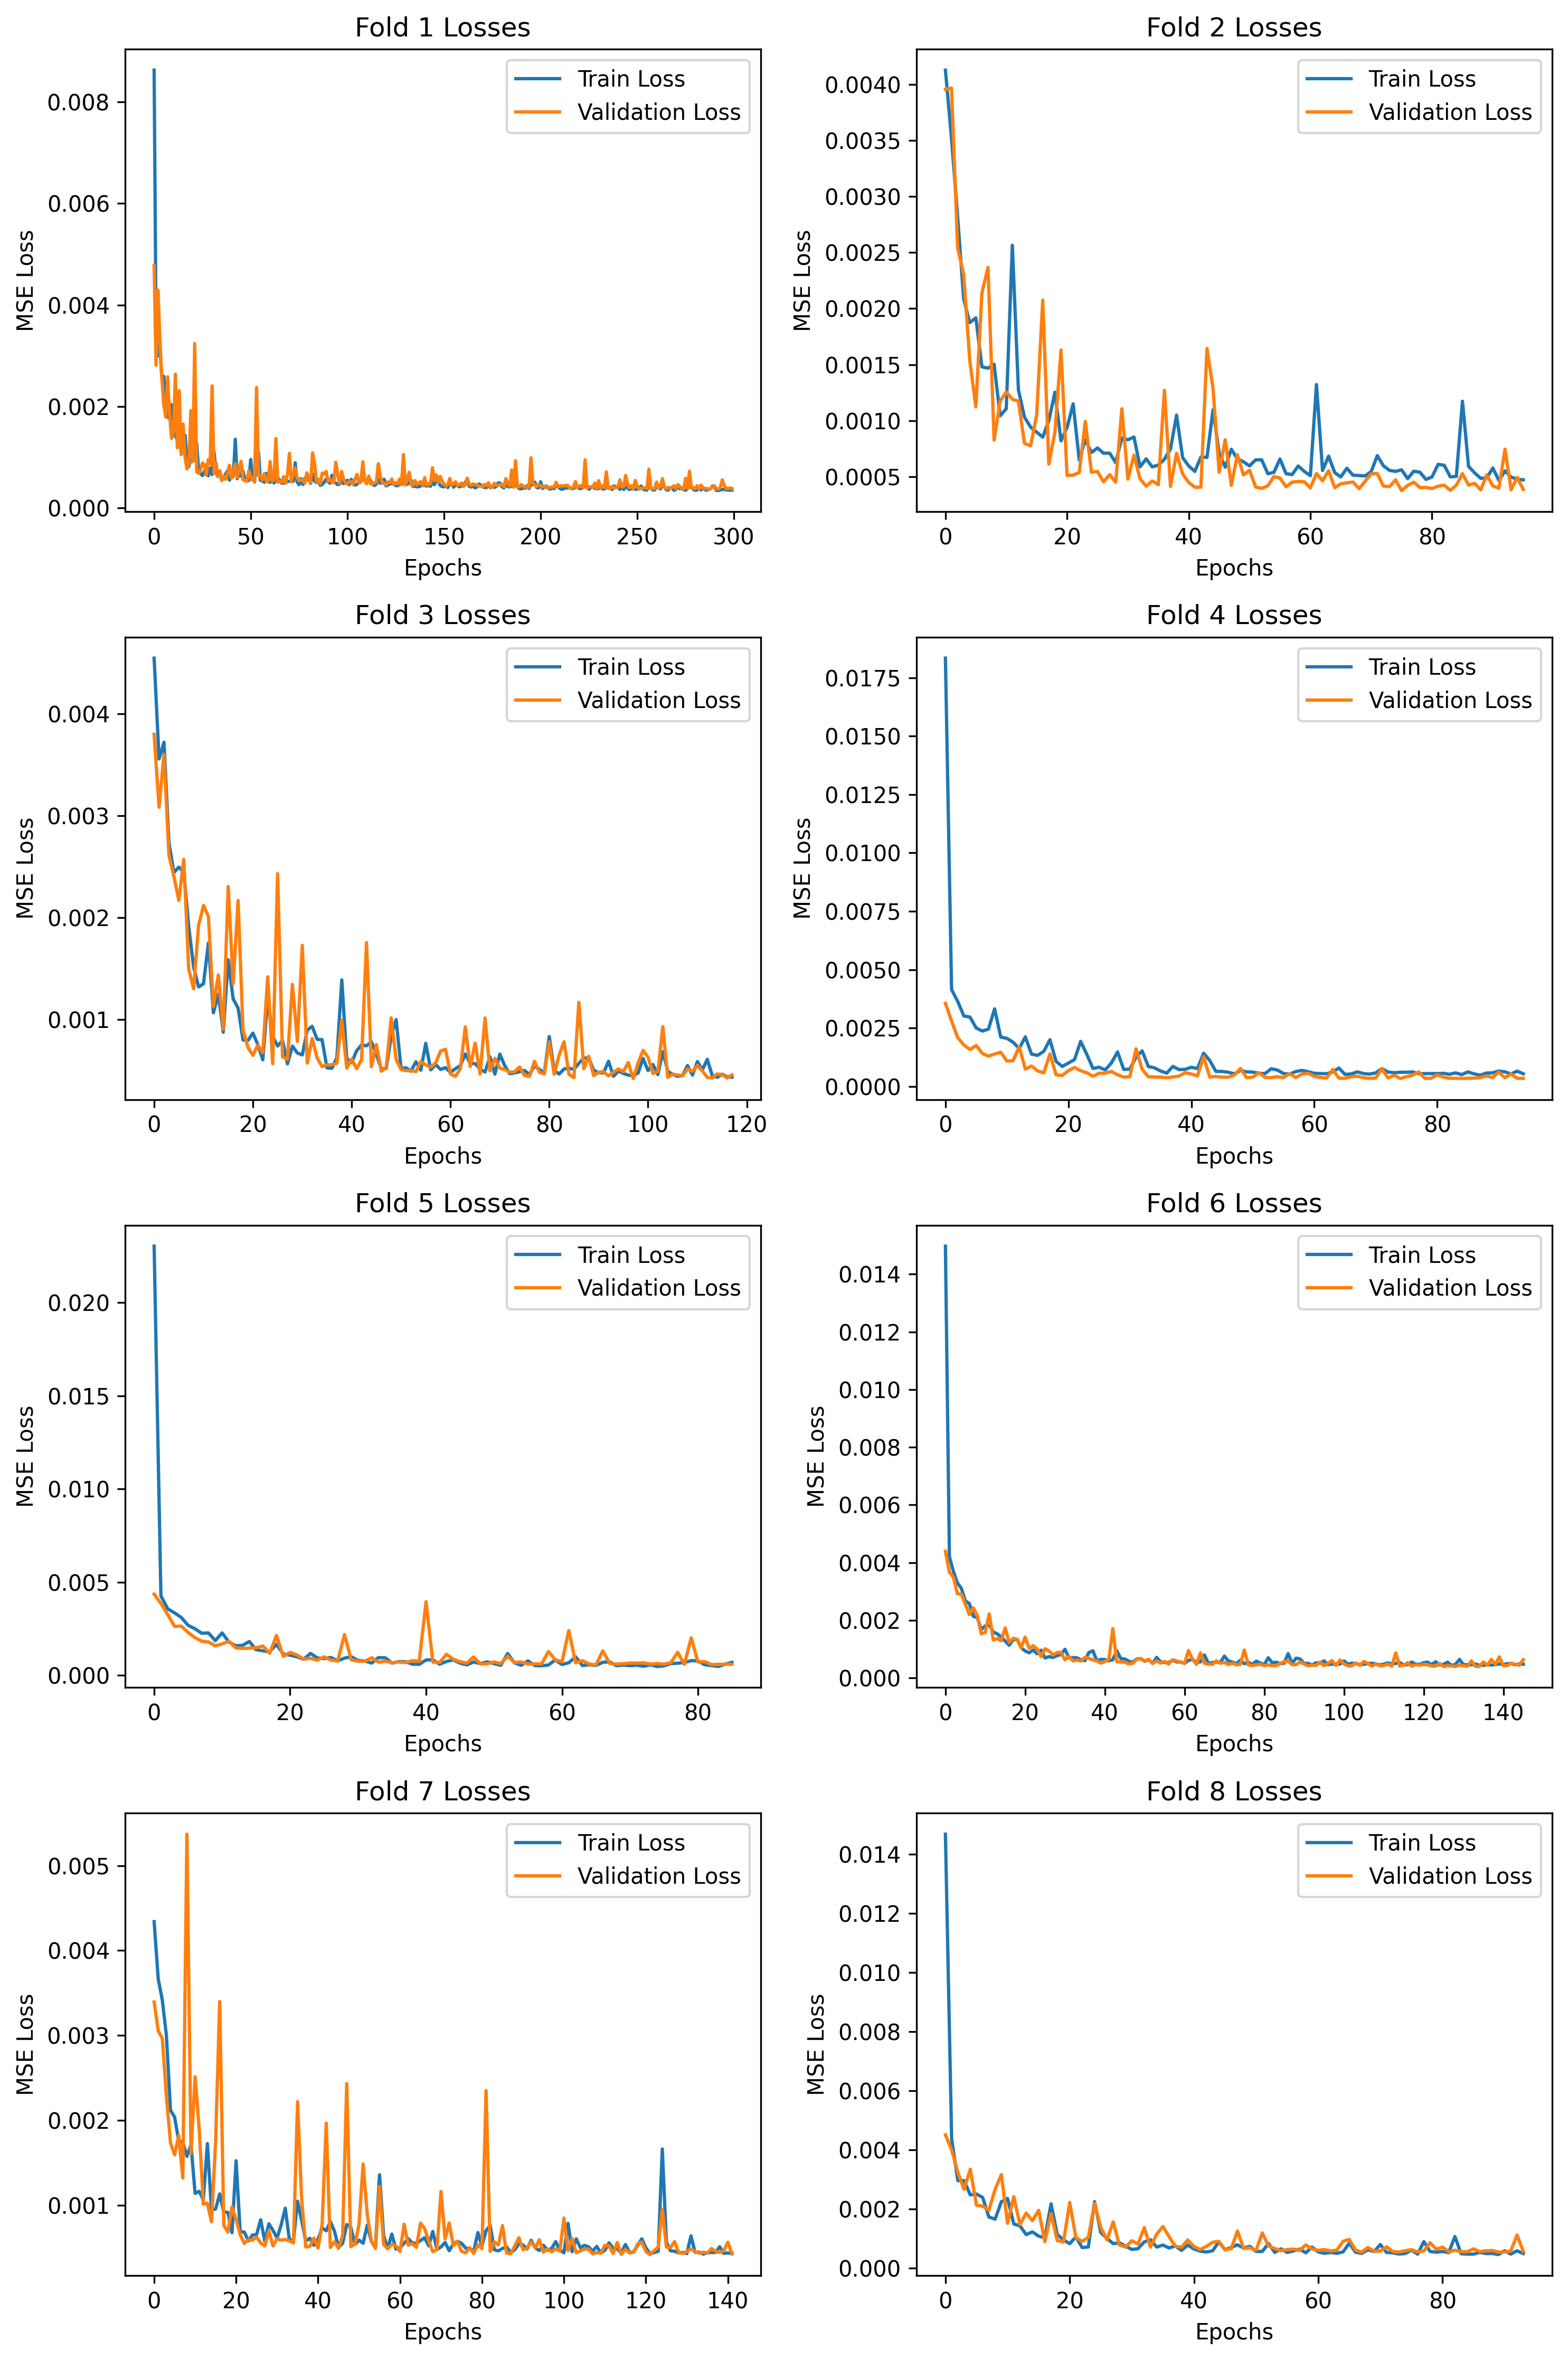

In [46]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
#plot at each fold and plot all graph s in one figure make subplots 
fig, axs = plt.subplots(4, 2, figsize=(10, 15))
axs = axs.flatten()
for fold in range(len(train_losses_per_fold)):
    axs[fold].plot(train_losses_per_fold[fold], label='Train Loss')
    axs[fold].plot(val_losses_per_fold[fold], label='Validation Loss')
    axs[fold].set_title(f'Fold {fold+1} Losses')
    axs[fold].set_xlabel('Epochs')
    axs[fold].set_ylabel('MSE Loss')
    axs[fold].legend()

plt.tight_layout()
plt.show()

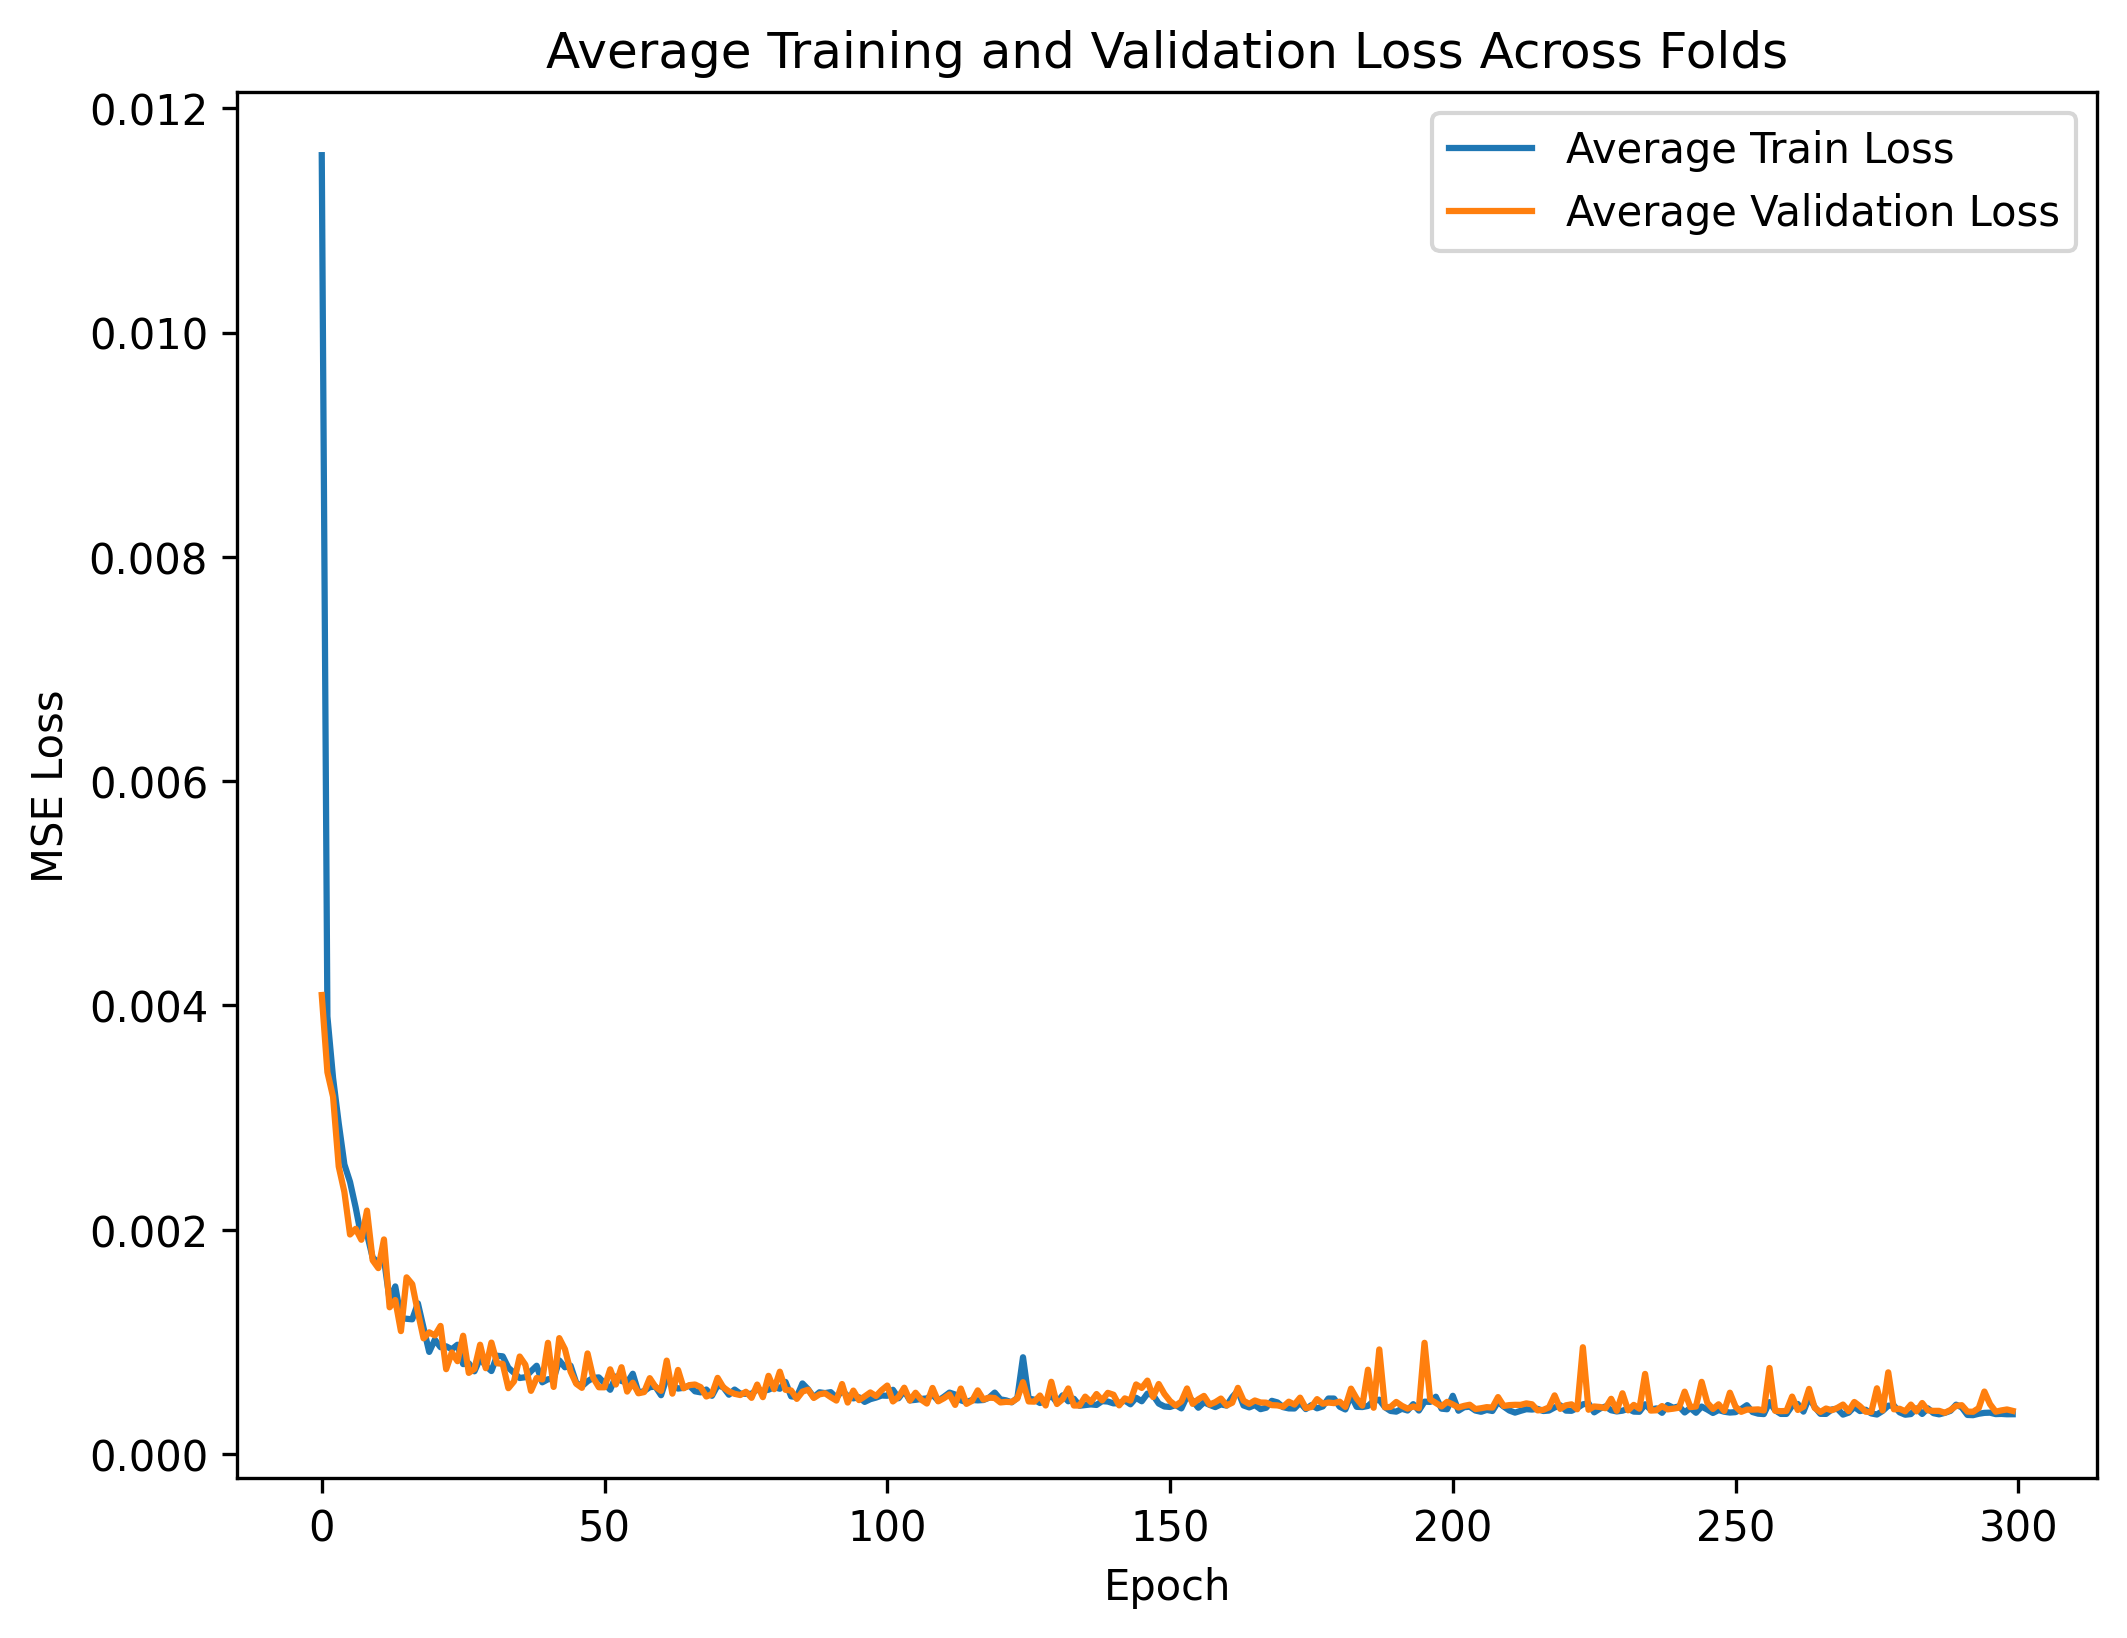

In [47]:
max_epochs = max(len(fold) for fold in train_losses_per_fold)

# Pad shorter folds with NaN
train_losses_padded = np.array([fold + [np.nan]*(max_epochs - len(fold)) 
                                for fold in train_losses_per_fold])
val_losses_padded   = np.array([fold + [np.nan]*(max_epochs - len(fold)) 
                                for fold in val_losses_per_fold])

# Compute average ignoring NaNs
avg_train = np.nanmean(train_losses_padded, axis=0)
avg_val   = np.nanmean(val_losses_padded, axis=0)

epochs = range(max_epochs)

plt.figure(figsize=(8,6))
plt.plot(epochs, avg_train, label="Average Train Loss")
plt.plot(epochs, avg_val, label="Average Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Average Training and Validation Loss Across Folds")
plt.legend()
plt.show()


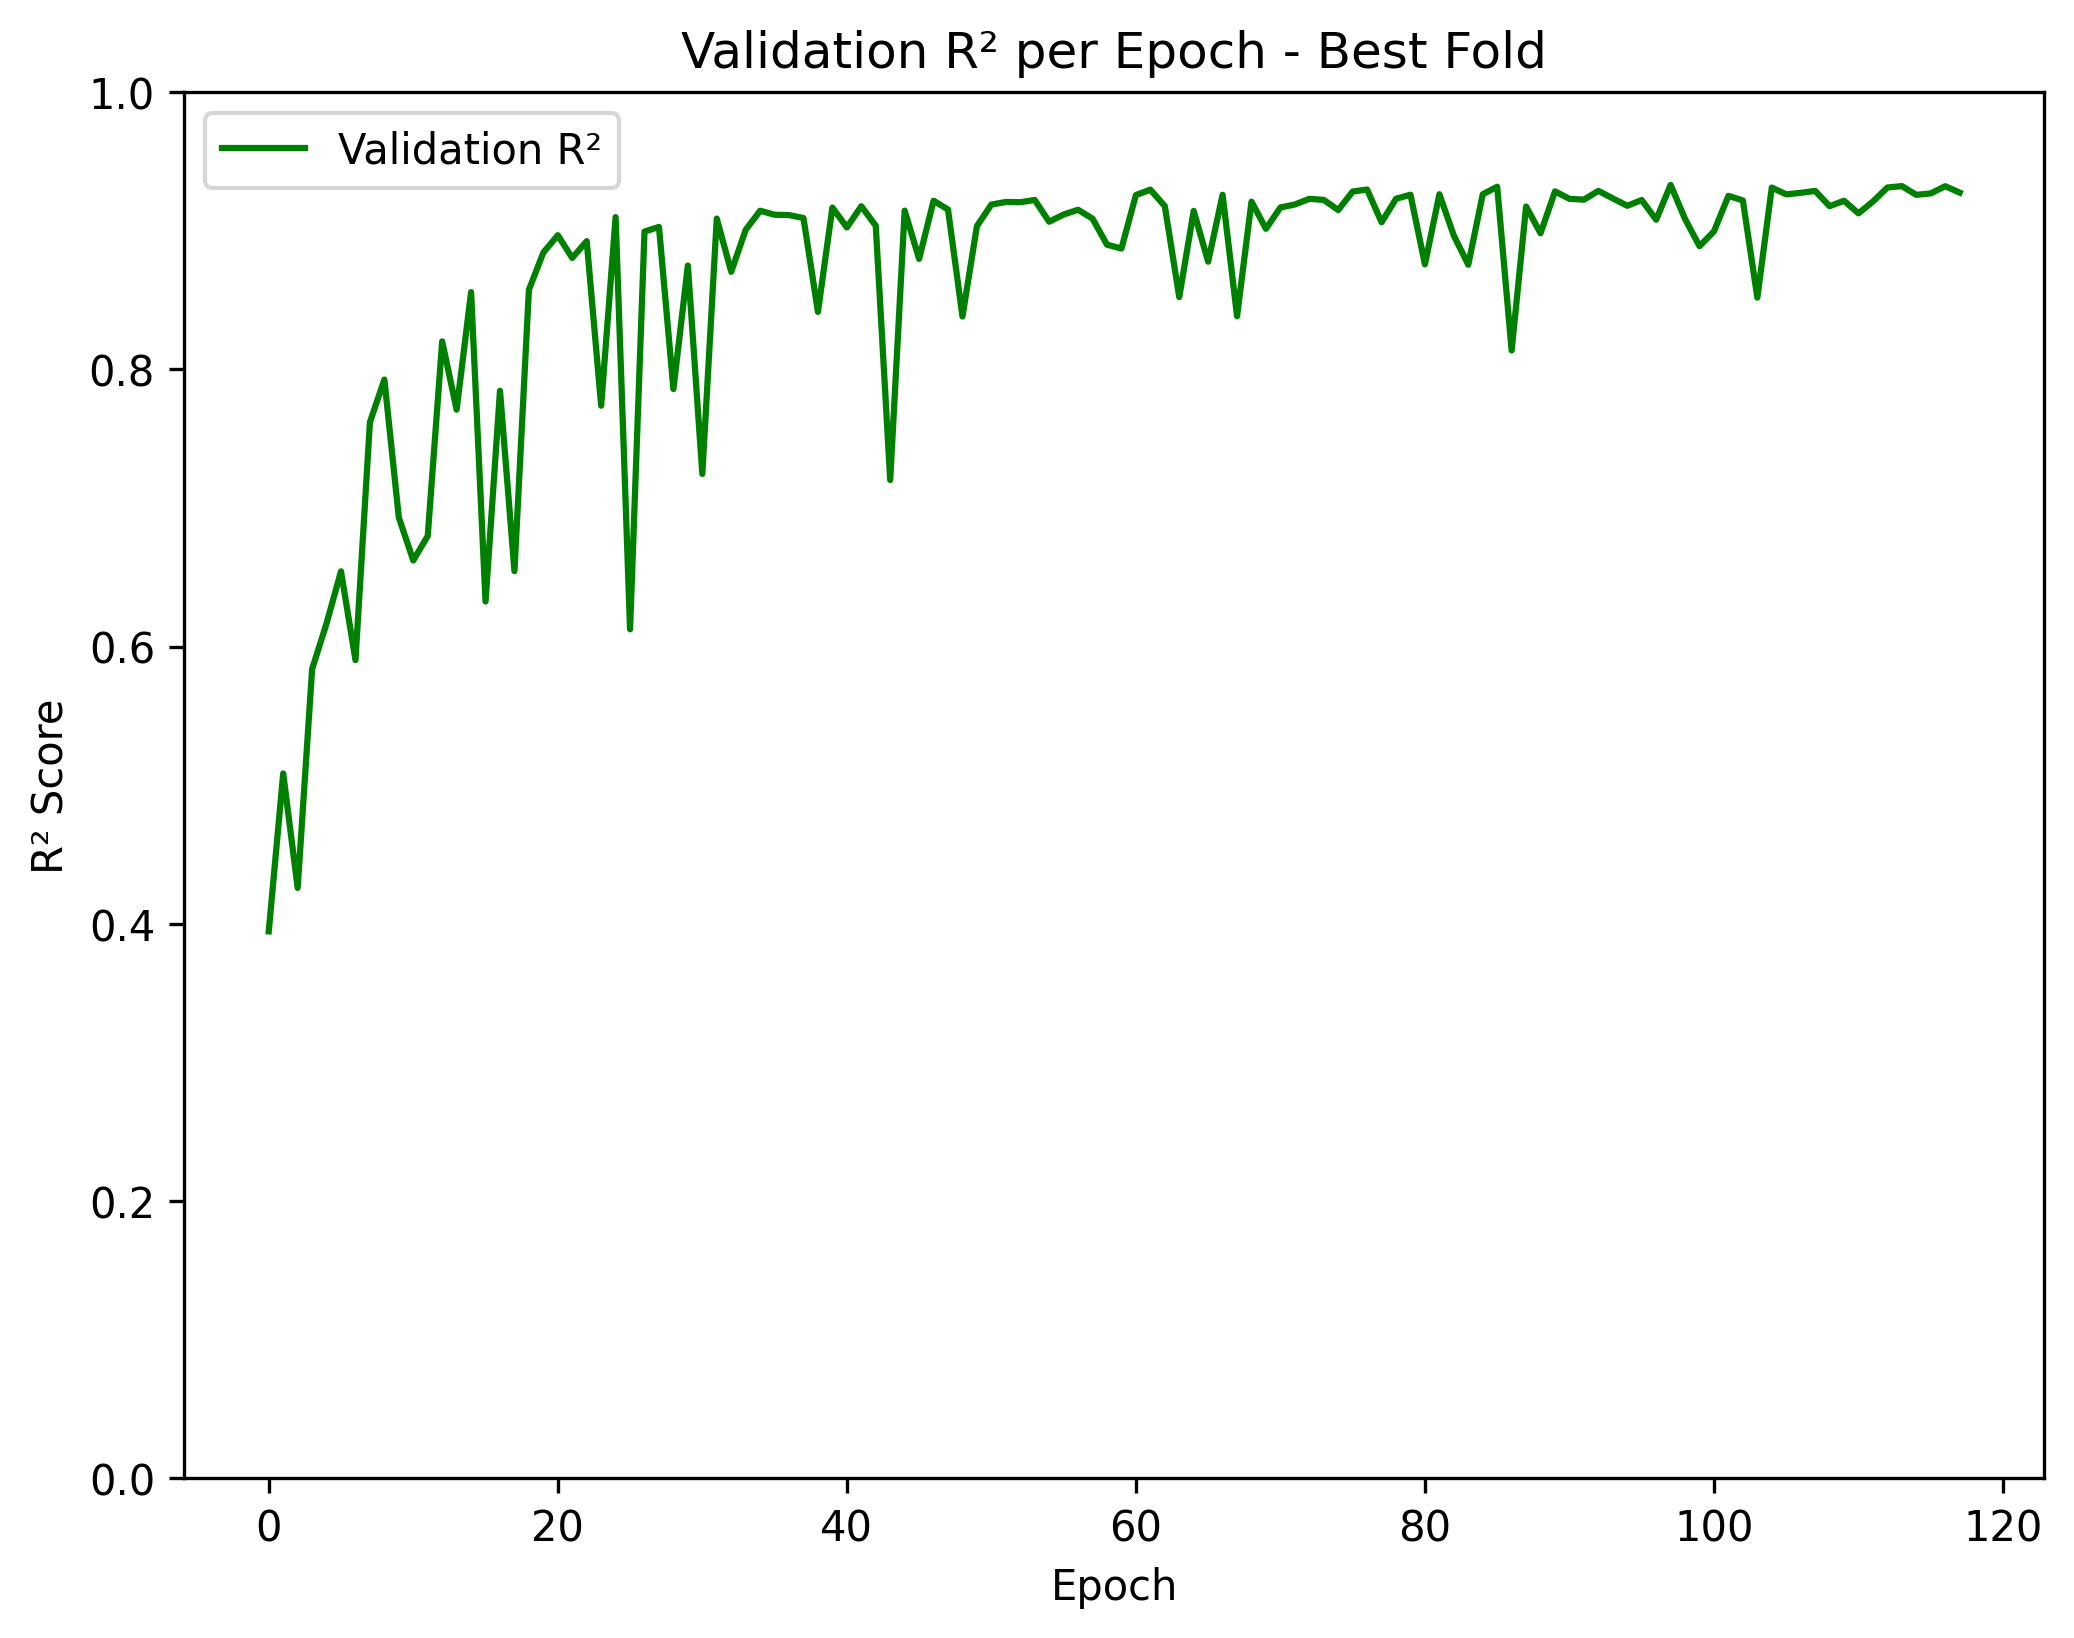

In [48]:
# R^2 Score Plot for Best Fold
epochs = range(len(val_r2_per_fold[2]))

plt.figure(figsize=(8,6))
plt.plot(epochs, val_r2_per_fold[2], label="Validation R²", color="green")
plt.xlabel("Epoch")
plt.ylabel("R² Score")
plt.title("Validation R² per Epoch - Best Fold")
plt.ylim(0, 1)  # optional: limits to 0-1 for clarity
plt.legend()
plt.show()


In [64]:
# fig, ax1 = plt.subplots(figsize=(8,6))

# color = 'tab:blue'
# ax1.set_xlabel('Epoch')
# ax1.set_ylabel('Train Loss', color=color)
# ax1.plot(epochs, train_losses_per_fold[6], color=color, label='Train Loss')
# ax1.tick_params(axis='y', labelcolor=color)

# ax2 = ax1.twinx()  # secondary y-axis
# color = 'tab:green'
# ax2.set_ylabel('Validation R²', color=color)
# ax2.plot(epochs, val_r2_per_fold[6], color=color, label='Validation R²')
# ax2.tick_params(axis='y', labelcolor=color)
# ax2.set_ylim(0, 1)

# fig.tight_layout()
# plt.title("Train Loss & Validation R² per Epoch - Fold 6")
# plt.show()


In [49]:
from torch_geometric.loader import DataLoader  # Correct new import

test_data_objects = [
    Data(
        x=torch.tensor(g["X_flat"], dtype=torch.float),
        y=torch.tensor(g["y_flat"], dtype=torch.float),
        edge_index=edge_index,
        num_nodes=g["X_flat"].shape[0]
    ) for g in test_graphs
]

test_loader = DataLoader(test_data_objects, batch_size=1, shuffle=False)

test_y_true, test_y_pred = [], []
test_embeddings = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        h, pred = model(batch.x, batch.edge_index)
        test_embeddings.append(h.cpu())
        test_y_true.append(batch.y.cpu().numpy())
        test_y_pred.append(pred.cpu().numpy())

test_y_true = np.vstack(test_y_true)
test_y_pred = np.vstack(test_y_pred)

mse = mean_squared_error(test_y_true, test_y_pred)
mae = mean_absolute_error(test_y_true, test_y_pred)
r2 = r2_score(test_y_true, test_y_pred)

print(f"\nTest Set Performance: MSE={mse:.6f}, MAE={mae:.6f}, R2={r2:.4f}")






Test Set Performance: MSE=0.000397, MAE=0.010195, R2=0.9178


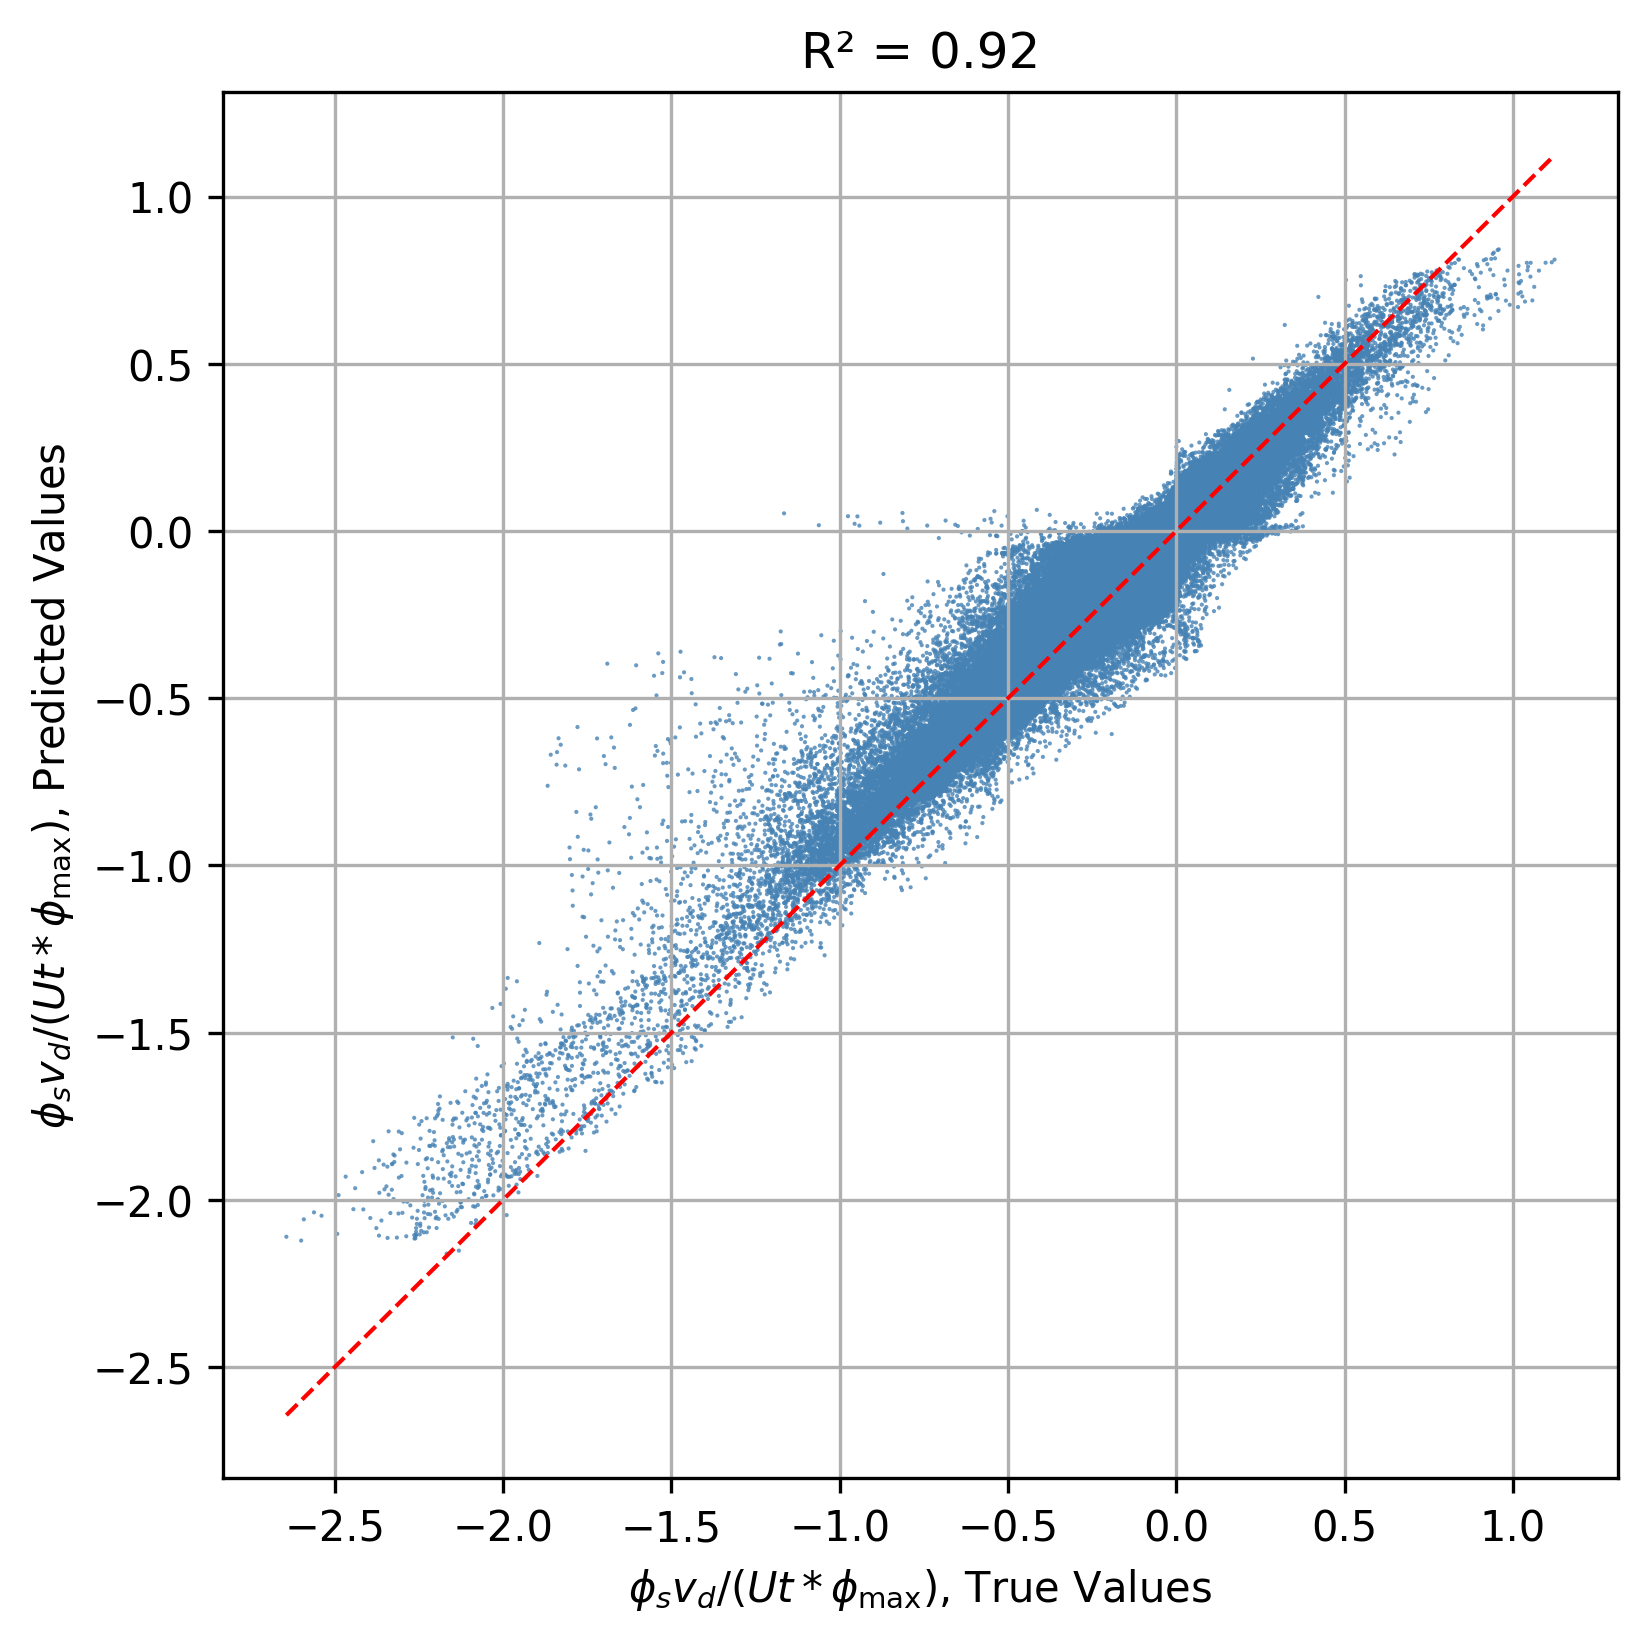

In [50]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300

# Flatten arrays (just in case)
y_true = test_y_true.flatten()
y_pred = test_y_pred.flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, s=1, alpha=0.8, c='steelblue',edgecolors='none')  # points
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=1)  # perfect line
plt.xlabel(r"$\phi_s v_d / (Ut* \phi_{\mathrm{max}})$, True Values")
plt.ylabel(r"$\phi_s v_d / (Ut* \phi_{\mathrm{max}})$, Predicted Values")
plt.title(f"R² = {r2:.2f}")
plt.grid(True)
plt.show()


In [51]:
graphs_test = []

for sample in data:
    if "t3" in sample["filename"]:   # pick test graphs
        df = sample["data"]
        X = df[feature_cols].values.reshape(ny, nx, -1)
        y = df[label_cols].values.reshape(ny, nx, -1)
        X_flat = X.reshape(-1, X.shape[2])
        y_flat = y.reshape(-1, 1)

        graphs_test.append({
            "X_flat": X_flat,
            "y_flat": y_flat,
            "df": df,              # include full DataFrame for drag calc
            "filename": sample["filename"]
        })
# check the length of graphs_test


In [52]:
start = 0
for graph in graphs_test:
    n_nodes = graph["X_flat"].shape[0]
    graph["alp_vd_pred"] = test_y_pred[start:start+n_nodes].flatten()
    start += n_nodes


In [59]:
fd_model_all = []
alp_max = 0.6
gravity = 9.8

for graph in graphs_test:
    df = graph["df"]
    alp = df["solid-vof"].values
    u_slip_y = df["u_slip_y"].values
    Ut = df["Ut"].values
    alp_org=alp*alp_max
    u_slip=u_slip_y * Ut
    tau_p = df["tau_p_tilde"].values
    alp_vd_pred = graph["alp_vd_pred"].flatten()
    alp_vd_physical = alp_vd_pred * Ut * alp_max
    fd_model = 1/tau_p * (alp_org * u_slip + alp_vd_physical) / gravity
    fd_model_all.append(fd_model)


In [60]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Stack all predicted and true drag values across test graphs
fd_model_stacked = np.hstack(fd_model_all)  # predicted
fd_true_stacked = np.hstack([g["df"]["fd_y"].values for g in graphs_test])  # true

# Compute R^2, MSE, MAE
r2 = r2_score(fd_true_stacked, fd_model_stacked)
mse = mean_squared_error(fd_true_stacked, fd_model_stacked)
mae = mean_absolute_error(fd_true_stacked, fd_model_stacked)

print(f"Drag Force Prediction Metrics:")
print(f"R^2 = {r2:.4f}")
print(f"MSE = {mse:.6f}")
print(f"MAE = {mae:.6f}")


Drag Force Prediction Metrics:
R^2 = 0.5177
MSE = 0.007337
MAE = 0.026292


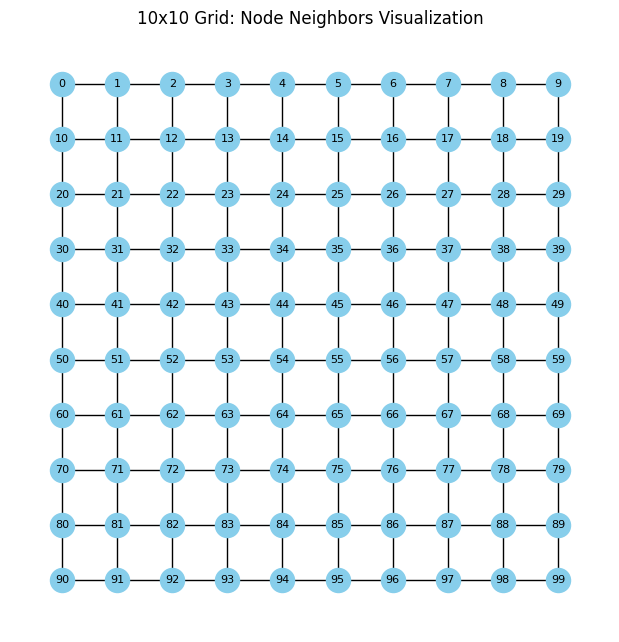

In [107]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

ny, nx_ = 10, 10  # small patch
num_nodes = ny * nx_

G = nx.Graph()

# Add nodes
for i in range(ny):
    for j in range(nx_):
        node_id = i * nx_ + j
        G.add_node(node_id, pos=(j, -i))  # x=j, y=-i for plotting

# Add edges (4-neighbor)
for i in range(ny):
    for j in range(nx_):
        node_id = i * nx_ + j
        if i > 0:
            G.add_edge(node_id, (i-1)*nx_ + j)  # up
        if i < ny-1:
            G.add_edge(node_id, (i+1)*nx_ + j)  # down
        if j > 0:
            G.add_edge(node_id, i*nx_ + (j-1))  # left
        if j < nx_-1:
            G.add_edge(node_id, i*nx_ + (j+1))  # right
pos = nx.get_node_attributes(G, 'pos')
plt.figure(figsize=(6,6))
nx.draw(G, pos, with_labels=True, node_size=300, node_color='skyblue', font_size=8)
plt.title("10x10 Grid: Node Neighbors Visualization")
plt.show()


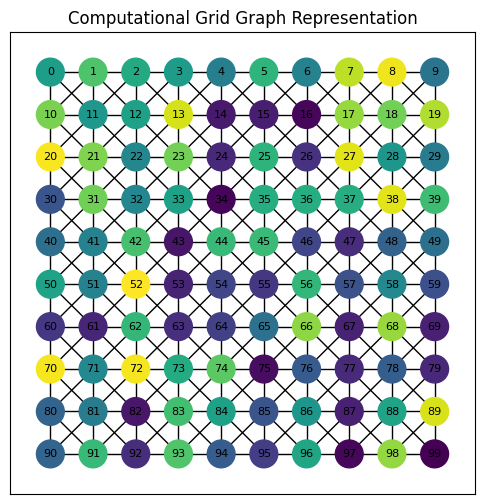

In [134]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

ny, nx_ = 10, 10  # small patch
G = nx.Graph()

# Add nodes
for i in range(ny):
    for j in range(nx_):
        node_id = i * nx_ + j
        G.add_node(node_id, pos=(j, -i))

# Add 8-neighbor edges
neighbors_offsets = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]
for i in range(ny):
    for j in range(nx_):
        node_id = i * nx_ + j
        for dy, dx in neighbors_offsets:
            ni, nj = i + dy, j + dx
            if 0 <= ni < ny and 0 <= nj < nx_:
                neighbor_id = ni*nx_ + nj
                G.add_edge(node_id, neighbor_id)

# Node colors (example random values or feature)
np.random.seed(0)
node_colors = np.random.rand(ny*nx_)

# Draw edges first
pos = nx.get_node_attributes(G, 'pos')
plt.figure(figsize=(6,6))
nx.draw_networkx_edges(G, pos)

# Draw nodes separately to create mappable
nodes = nx.draw_networkx_nodes(
    G, pos, node_color=node_colors, cmap=plt.cm.viridis, node_size=400
)

# Add labels (optional)
nx.draw_networkx_labels(G, pos, font_size=8)

# Add colorbar using the mappable
# plt.colorbar(nodes, label="vof")

plt.title("Computational Grid Graph Representation")
plt.show()
